## Project Title
**Titanic Survival Prediction using a Single Layer Perceptron (SLP)**

## Author
**Muhammad Anas**

---

# Project Overview

This project uses the **Titanic dataset** to build a **Single Layer Perceptron (SLP)** model for predicting whether a passenger survived or not. The model is developed using **TensorFlow/Keras** and follows a complete machine learning workflow, including data preprocessing, feature engineering, model training, and evaluation.

---

# Dataset Information

The Titanic dataset is available through the **Seaborn** library and is based on passenger information from the Titanic disaster. Each row represents one passenger, while each column contains information about that passenger.

The target column is **survived**, where:

- **1** = Passenger Survived
- **0** = Passenger Did Not Survive

---

# Features Used

The dataset contains several passenger attributes, including:

- Passenger Class (`pclass`)
- Sex (`sex`)
- Age (`age`)
- Number of Siblings/Spouses (`sibsp`)
- Number of Parents/Children (`parch`)
- Fare (`fare`)
- Embarkation Port (`embarked`)

These features are used to predict the survival of each passenger.

---

# Project Workflow

1. Import Libraries
2. Load Dataset
3. Explore the Dataset
4. Data Cleaning
5. Feature Engineering
6. Encode Categorical Features
7. Scale Numerical Features
8. Split Training and Testing Data
9. Build the Single Layer Perceptron
10. Train the Model
11. Make Predictions
12. Evaluate Model Performance

---

# Objective

The objective of this project is to learn how a **Single Layer Perceptron** performs binary classification by predicting passenger survival based on their characteristics.

### Importing Libraries

In [46]:
#importing important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense
import warnings
warnings.filterwarnings('ignore')

### Lets Load our Dataset

In [47]:
data=sns.load_dataset('titanic')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Exploratory Data Analysis (EDA)

In [48]:
#checking the shape of the dataset
print("The dataset contain {} rows and {} columns".format(data.shape[0],data.shape[1])) 
data.shape

The dataset contain 891 rows and 15 columns


(891, 15)

In [49]:
#checking for null values
data.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [50]:
#checking for the unique values in the dataset
data.nunique()

survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

In [51]:
#checking for the unique values in the  survived column 
data['survived'].unique()

array([0, 1])

In [52]:
#checking for the unique values in the  sex column 
data['sex'].unique()

array(['male', 'female'], dtype=object)

In [53]:
#checking for the unique value in embarked column
data['embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [54]:
#checking for the unique value in class column
data['class'].unique()

['Third', 'First', 'Second']
Categories (3, object): ['First', 'Second', 'Third']

In [55]:
#cehcking for the unique value in who column embark_town
data['who'].unique()

array(['man', 'woman', 'child'], dtype=object)

In [56]:
#checking for the duplicated values in the dataset
data.duplicated().sum()

np.int64(107)

Dealing with the missing values in the Dataset

In [57]:
#removing the deck column from the dataset as it has more than 50% missing values
data.drop('deck',axis=1,inplace=True)
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [58]:
#dealing the age column missing values by replacing the missing values with the mean of the age column
data['age'].fillna(data['age'].mean(),inplace=True)


In [59]:
#removing the missing value from the emabarked_town column as it has only 2 missing values
data.dropna(subset=['embarked'],inplace=True)

Removing the emabarked column becaue its same to the emabarked_town column 

In [60]:
#droping the embarked column becaue its same to the emabarked_town column
data.drop('embarked',axis=1,inplace=True)

In [61]:
#removing the who column becaue its same to the sex column
data.drop('who',axis=1,inplace=True)

In [62]:
#removing the alive column becaue its same to the survived column
data.drop('alive',axis=1,inplace=True)


In [63]:
#removing the adult_male column 
data.drop('adult_male',axis=1,inplace=True)
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,class,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,Third,Southampton,False
1,1,1,female,38.0,1,0,71.2833,First,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,Third,Southampton,True
3,1,1,female,35.0,1,0,53.1000,First,Southampton,False
4,0,3,male,35.0,0,0,8.0500,Third,Southampton,True


In [64]:
#now checking for the duplicated value in the dataset 
data.duplicated().sum()

np.int64(111)

In [65]:
#remocing the duplicated data 
data.drop_duplicates(inplace=True)
data.duplicated().sum()

np.int64(0)

### Data Visulaization 

<Axes: xlabel='survived', ylabel='count'>

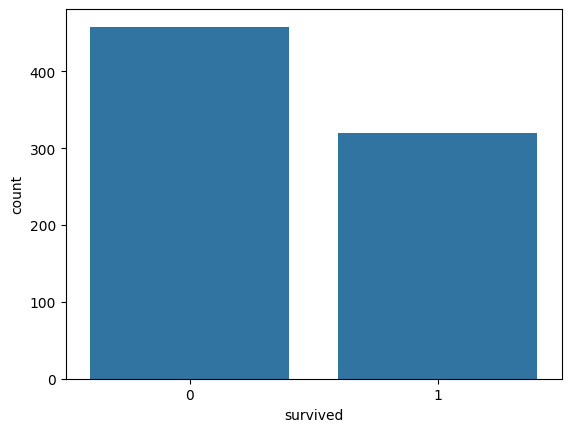

In [66]:
#Countplot of survived column
sns.countplot(x='survived',data=data)

In [67]:
#Number of value count in the survived column
data['survived'].value_counts()

survived
0    458
1    320
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='Count'>

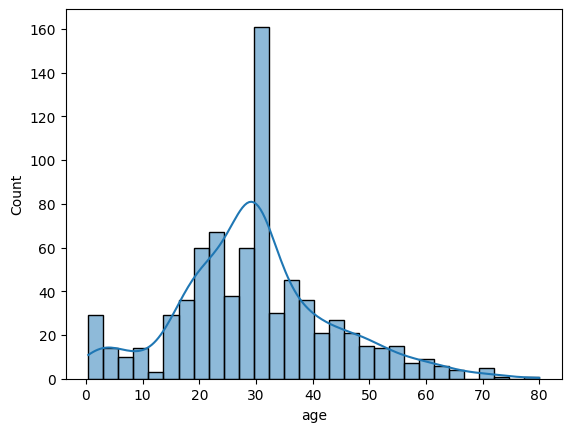

In [68]:
#Distribution of age column
sns.histplot(data['age'],bins=30,kde=True)

In [69]:
data['age'].describe()

count    778.000000
mean      29.745666
std       13.674550
min        0.420000
25%       21.250000
50%       29.699118
75%       36.000000
max       80.000000
Name: age, dtype: float64

<Axes: xlabel='pclass', ylabel='count'>

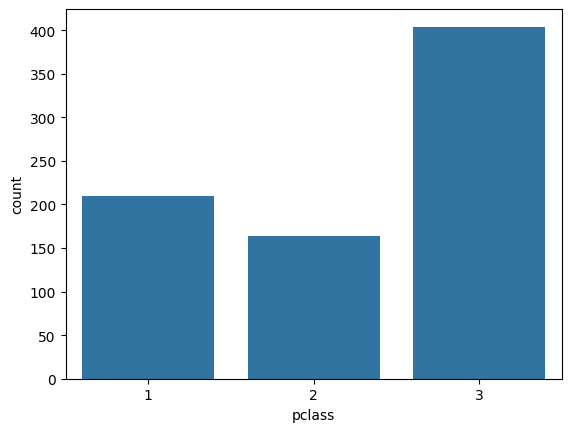

In [70]:
#Countplot   of the pair column
sns.countplot(x='pclass',data=data)

<Axes: xlabel='pclass', ylabel='count'>

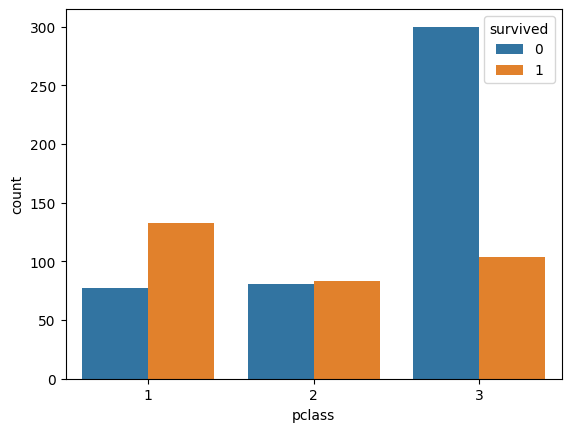

In [71]:
#Countplot   of the pair column with hue of survived column
sns.countplot(x='pclass', hue='survived', data=data)

<Axes: xlabel='sex', ylabel='count'>

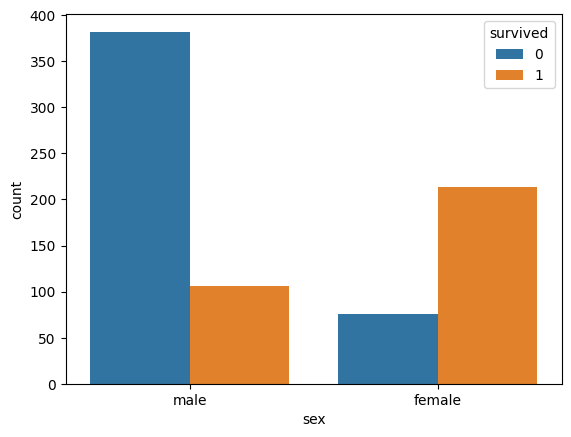

In [72]:
#contplot of the sex column with hue of survived column
sns.countplot(x='sex', hue='survived', data=data)

<Axes: xlabel='fare', ylabel='Count'>

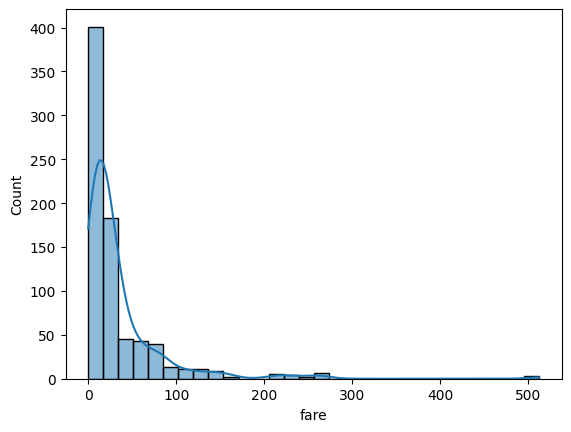

In [73]:
#distribution of fare column
sns.histplot(data['fare'],bins=30,kde=True)

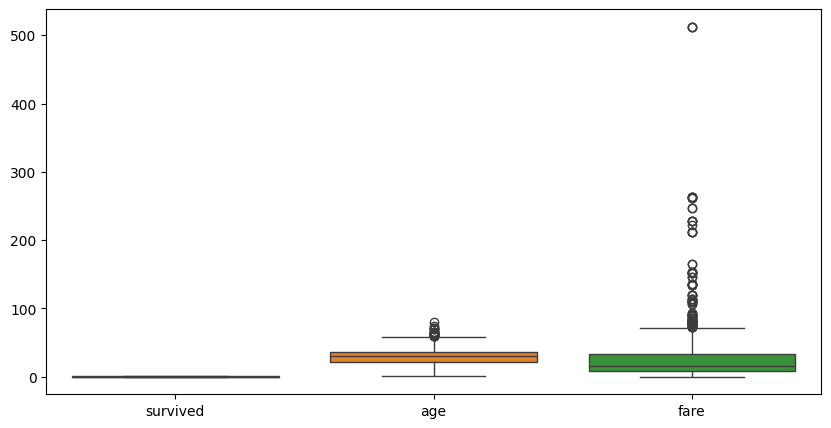

In [74]:
#checking for the outlier in the numerical columns using boxplot
plt.figure(figsize=(10,5))
sns.boxplot(data=data[['survived','age','fare']])
plt.show()

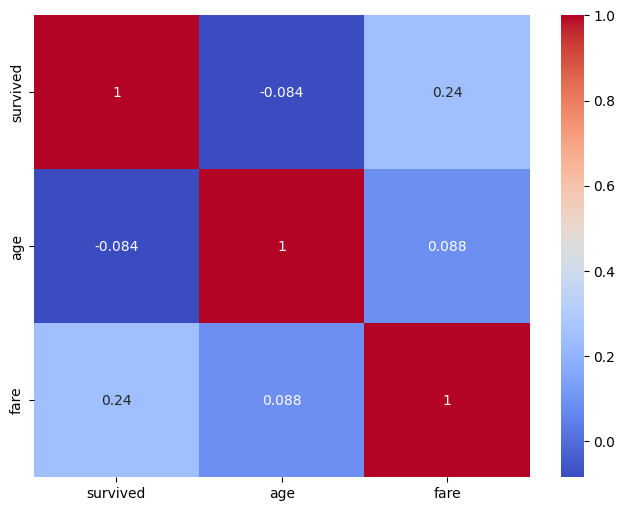

In [75]:
#checking the realtion ship between the numerical columns using heatmap
numerical_columns = ['survived', 'age', 'fare']
plt.figure(figsize=(8, 6))
sns.heatmap(data[numerical_columns].corr(), annot=True, cmap='coolwarm')
plt.show()

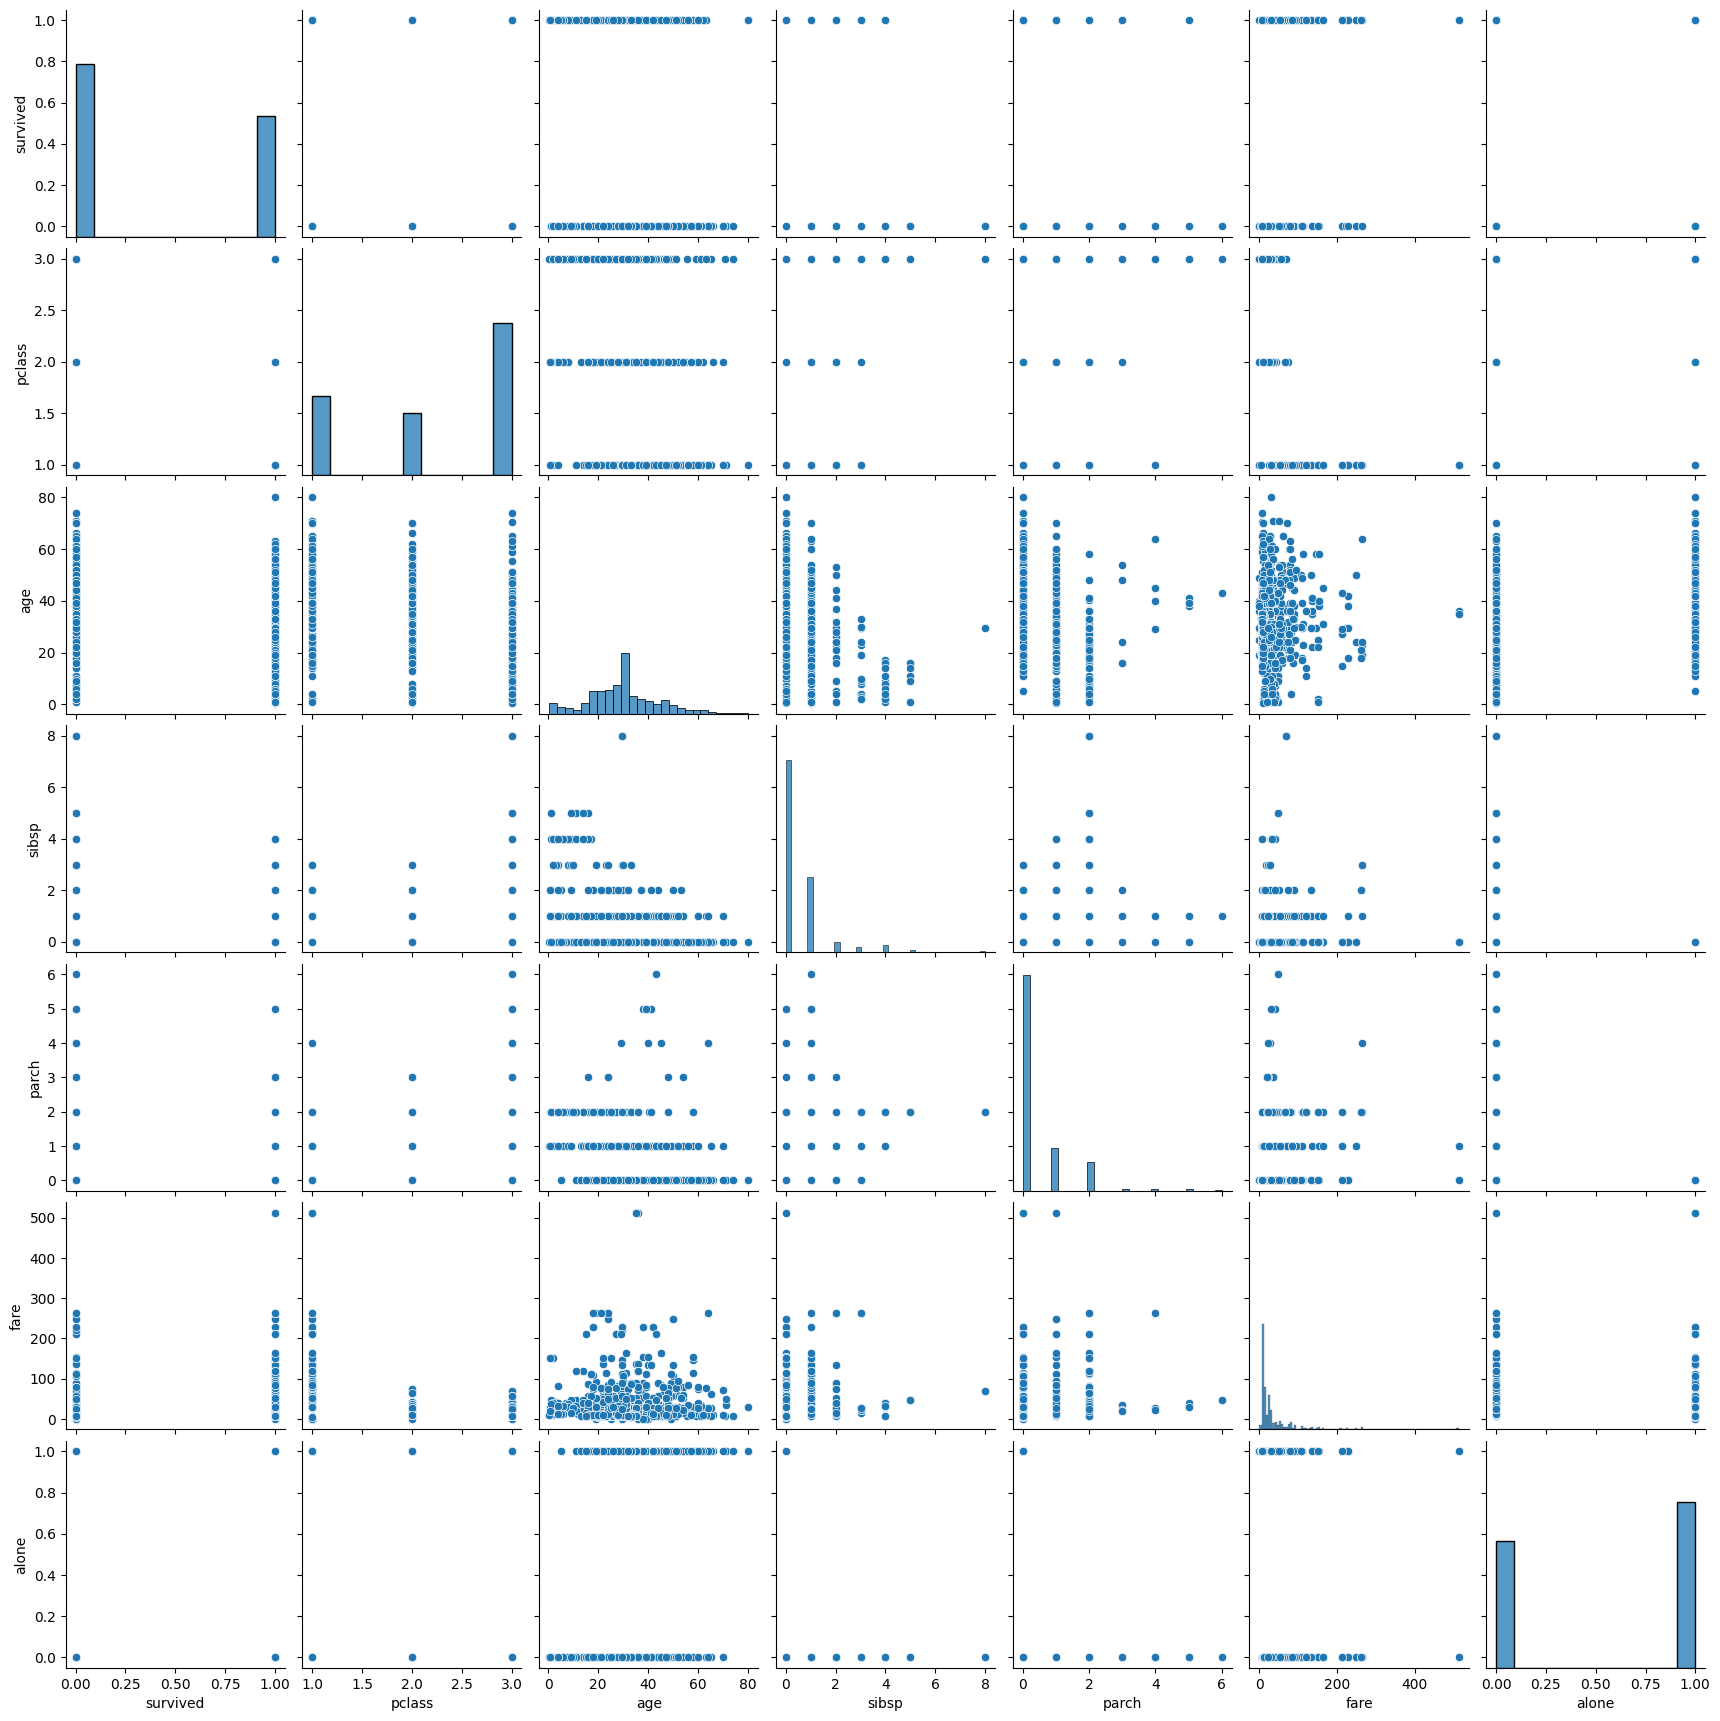

In [76]:
#drawing a pairplot for the dataset 
sns.pairplot(data)

### Data Preprocessing

In [77]:
#removing the class column as it is same to the pclass column
data.drop('class',axis=1,inplace=True)
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,Southampton,False
1,1,1,female,38.0,1,0,71.2833,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,Southampton,True
3,1,1,female,35.0,1,0,53.1000,Southampton,False
4,0,3,male,35.0,0,0,8.0500,Southampton,True


In [78]:
#checking for the datatype of the columns in the dataset
data.dtypes

survived         int64
pclass           int64
sex             object
age            float64
sibsp            int64
parch            int64
fare           float64
embark_town     object
alone             bool
dtype: object

In [79]:
#Doing the encoding for the sex column using the label encoder
LabelEncoder_sex = LabelEncoder()
data['sex'] = LabelEncoder_sex.fit_transform(data['sex'])
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,1,22.0,1,0,7.2500,Southampton,False
1,1,1,0,38.0,1,0,71.2833,Cherbourg,False
2,1,3,0,26.0,0,0,7.9250,Southampton,True
3,1,1,0,35.0,1,0,53.1000,Southampton,False
4,0,3,1,35.0,0,0,8.0500,Southampton,True


In [80]:
#doing the label encoding for the embark_town column
LabelEncoder_embarked_town = LabelEncoder()
# doing the label encoding for the embark_town column
data['embark_town'] = LabelEncoder_embarked_town.fit_transform(data['embark_town'])
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embark_town,alone
0,0,3,1,22.0,1,0,7.2500,2,False
1,1,1,0,38.0,1,0,71.2833,0,False
2,1,3,0,26.0,0,0,7.9250,2,True
3,1,1,0,35.0,1,0,53.1000,2,False
4,0,3,1,35.0,0,0,8.0500,2,True


### splitting the dataset into features and target variable


In [81]:
#splitting the dataset into features and target variable
X = data.drop('survived', axis=1)
y = data['survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Building the model

In [82]:
#building the Single Layer Perceptron model using Keras
model = Sequential([
    Dense(1, activation="sigmoid", input_shape=(X_train.shape[1],))
])

#### Model Compilation

In [83]:
#complie the model 
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

#### Model Training

In [91]:
#Training the model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6982 - loss: 0.5774 - val_accuracy: 0.6720 - val_loss: 0.5994
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7022 - loss: 0.5761 - val_accuracy: 0.6880 - val_loss: 0.5998
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7042 - loss: 0.5753 - val_accuracy: 0.6880 - val_loss: 0.5992
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7042 - loss: 0.5737 - val_accuracy: 0.6960 - val_loss: 0.5985
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6922 - loss: 0.5730 - val_accuracy: 0.7040 - val_loss: 0.5974
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6821 - loss: 0.5727 - val_accuracy: 0.7040 - val_loss: 0.5974
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7042 - loss: 0.5712 - val_accuracy: 0.6880 - val_loss: 0.5977
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7123 - loss: 0.5711 - val_accuracy: 0.6880 - val_loss

#### Model Prediction

In [92]:
#Model prediction
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)
y_pred[:5]  # Display the first 5 predictions


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


array([[1],
       [0],
       [1],
       [0],
       [1]])

In [93]:
#summary of the model 
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29 (120.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20 (84.00 B)

### Traning vs Testing Accuracy

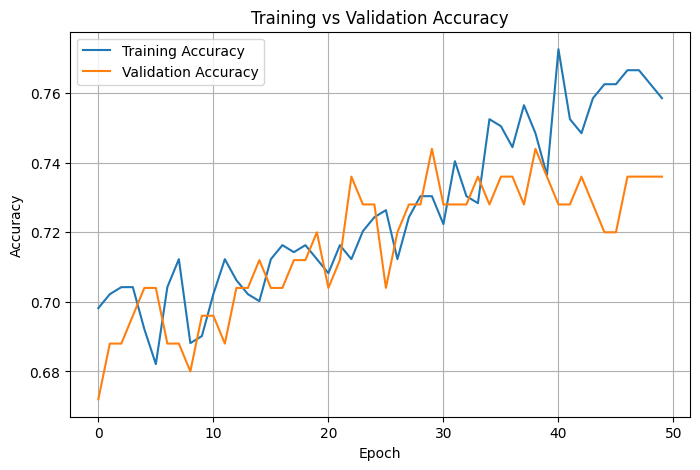

In [94]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()